In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset

### What is a CNN?

A **Convolutional Neural Network (CNN)** is a specialized neural network designed to process **grid-like data** (images, audio spectrograms, etc.).

Instead of connecting every neuron to every pixel (like a regular dense network), CNNs use **filters** that slide across the image to detect patterns.

- Regular NN: Every pixel → Every neuron (millions of parameters!)
- CNN: Small filter slides across image (few parameters, better results!)
- CNN = Filters + Sliding Window + Shared Weights!

In [ ]:
print("\n" + "="*60)
print("LOADING CIFAR-10 DATA")
print("="*60)

# i will use hugging face api. it is faster!

# # CIFAR-10: 60,000 32x32 color images in 10 classes
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 3 channels for RGB
# ])

# train_dataset = torchvision.datasets.CIFAR10(
#     root='./data', train=True, download=True, transform=transform
# )
# test_dataset = torchvision.datasets.CIFAR10(
#     root='./data', train=False, download=True, transform=transform
# )

# # Data loaders
# batch_size = 64
# train_loader = torch.utils.data.DataLoader(
#     train_dataset, batch_size=batch_size, shuffle=True
# )
# test_loader = torch.utils.data.DataLoader(
#     test_dataset, batch_size=batch_size, shuffle=False
# )

# # Class names
# classes = ['plane', 'car', 'bird', 'cat', 'deer', 
#            'dog', 'frog', 'horse', 'ship', 'truck']


LOADING CIFAR-10 DATA


In [5]:

print("\n" + "="*60)
print("LOADING CIFAR-10 DATA")
print("="*60)

# ✅ Same transform pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ✅ Load CIFAR-10 from Hugging Face instead of torchvision
hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test = load_dataset("uoft-cs/cifar10", split="test")



LOADING CIFAR-10 DATA


Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 188580.93 examples/s]


NameError: name 'Dataset' is not defined

In [7]:
# ✅ Custom Dataset wrapper to make HF data behave like torchvision
class CIFAR10FromHF(Dataset):
    """Wrap a Hugging Face CIFAR-10 split into a PyTorch Dataset."""

    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]  # PIL Image
        label = item["label"]  # int

        if self.transform is not None:
            img = self.transform(img)

        return img, label


train_dataset = CIFAR10FromHF(hf_train, transform=transform)
test_dataset = CIFAR10FromHF(hf_test, transform=transform)

# ✅ Same data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

# ✅ Same class names
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# ✅ Verify — identical result
print(f"Train images: {len(train_dataset)}")
print(f"Test images:  {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"\nBatch shape:  {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range:  {labels.min().item()} to {labels.max().item()}")

Train images: 50000
Test images:  10000
Train batches: 782
Test batches:  157

Batch shape:  torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Label range:  0 to 9



EXPLORING THE DATA


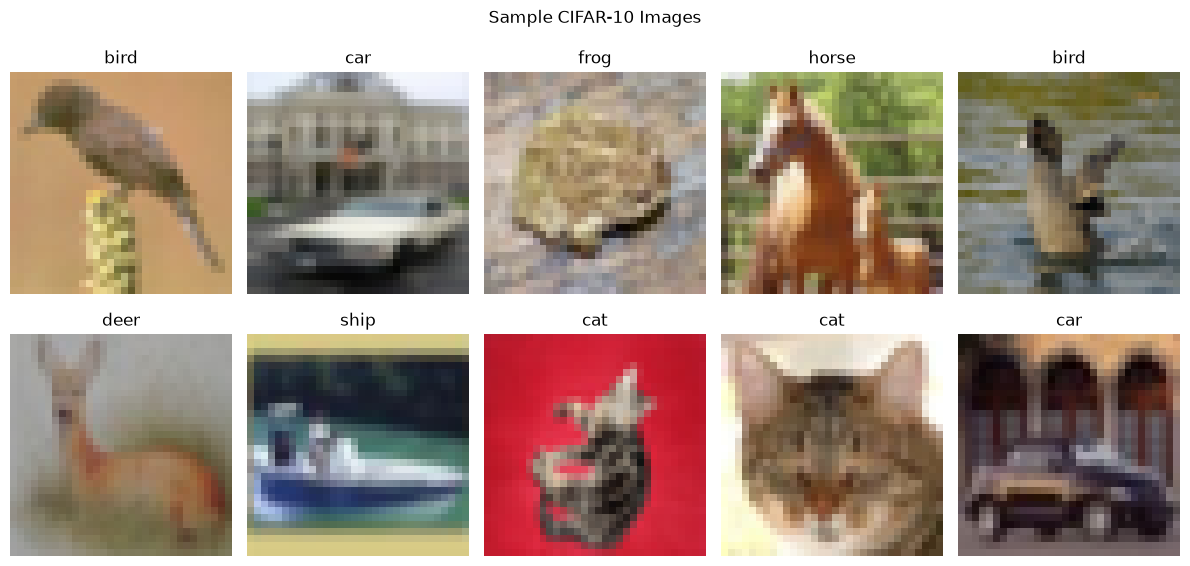

In [9]:
print("\n" + "="*60)
print("EXPLORING THE DATA")
print("="*60)

# it is blury because they are small sizes (so tiny) images

# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show some images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    # Denormalize for display
    img = images[i] / 2 + 0.5  # Convert from [-1,1] to [0,1]
    img = img.permute(1, 2, 0)  # Change from [C,H,W] to [H,W,C]
    axes[i].imshow(img)
    axes[i].set_title(f'{classes[labels[i].item()]}')
    axes[i].axis('off')

plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout()
plt.show()

### Convolution Concept

Imagine you have a small **filter (3×3)** that slides across the image:

#### Input Image (5×5) and Filter (3×3)

**Image (5×5):**
```
[1 2 3 4 5]
[6 7 8 9 0]
[1 2 3 4 5]
[6 7 8 9 0]
[1 2 3 4 5]
```

**Filter (3×3):**
```
[1 0 1]
[0 1 0]
[1 0 1]
```

#### Step 1: Position filter at top-left

```
[1 2 3]   [1 0 1]
[6 7 8] * [0 1 0] = 1*1 + 2*0 + 3*1 + 6*0 + 7*1 + 8*0 + 1*1 + 2*0 + 3*1
[1 2 3]   [1 0 1]
                  = 1 + 3 + 7 + 1 + 3
                  = 15
```

#### Step 2: Slide filter right by 1 pixel (stride=1)

```
[2 3 4]   [1 0 1]
[7 8 9] * [0 1 0] = 2 + 4 + 8 + 2 + 4
[2 3 4]   [1 0 1]
                  = 20
```


#### And so on...

The output is a **"feature map"** that highlights where the filter pattern is found.


> **Key Takeaways:**
> - The filter **slides** across the image (this is the "convolution" operation).
> - At each position, we compute an **element-wise multiplication** followed by a **sum**.
> - **Stride** controls how far the filter moves each step (here, stride = 1).
> - The result is a **feature map** — a smaller grid showing where the filter's pattern matches strongly.

In [11]:
print("\n" + "="*60)
print("BUILDING A CNN")
print("="*60)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        # Conv1: 3 input channels (RGB), 32 output channels, 3x3 filter
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 → 16x16
        
        # Conv2: 32 input channels, 64 output channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 → 8x8
        
        # Conv3: 64 input channels, 128 output channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 → 4x4
        
        # Fully connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        # Convolutional layers
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        
        # Fully connected layers
        x = self.flatten(x)
        x = self.dropout(self.fc1(x))
        x = self.fc2(x)
        return x

# Create model
model = SimpleCNN()
print("CNN Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# Show layer shapes
print("\nLayer shapes:")
print("Input: 3 x 32 x 32")
print("Conv1: 32 x 32 x 32")
print("Pool1: 32 x 16 x 16")
print("Conv2: 64 x 16 x 16")
print("Pool2: 64 x 8 x 8")
print("Conv3: 128 x 8 x 8")
print("Pool3: 128 x 4 x 4")
print("Flatten: 2048")
print("FC1: 256")
print("FC2: 10")


PART 4: BUILDING A CNN
CNN Architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=256, bias=

In [12]:
print("\n" + "="*60)
print("TRAINING THE CNN")
print("="*60)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

print("Training CNN on CIFAR-10...")
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_acc = 100 * correct_train / total_train
    train_accuracies.append(train_acc)
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Testing
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    
    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Train: {train_acc:.2f}%, Test: {test_acc:.2f}%")

print("\n✅ Training complete!")


PART 5: TRAINING THE CNN
Training CNN on CIFAR-10...
Epoch 1/10 - Loss: 1.3468, Train: 52.42%, Test: 66.33%
Epoch 2/10 - Loss: 0.9137, Train: 67.87%, Test: 68.03%
Epoch 3/10 - Loss: 0.7751, Train: 73.07%, Test: 73.46%
Epoch 4/10 - Loss: 0.6782, Train: 76.53%, Test: 75.65%
Epoch 5/10 - Loss: 0.5991, Train: 79.32%, Test: 76.39%
Epoch 6/10 - Loss: 0.5329, Train: 81.46%, Test: 76.96%
Epoch 7/10 - Loss: 0.4636, Train: 83.91%, Test: 77.31%
Epoch 8/10 - Loss: 0.4171, Train: 85.15%, Test: 77.90%
Epoch 9/10 - Loss: 0.3620, Train: 87.22%, Test: 78.10%
Epoch 10/10 - Loss: 0.3244, Train: 88.53%, Test: 76.67%

✅ Training complete!



ANALYZING TRAINING PROGRESS


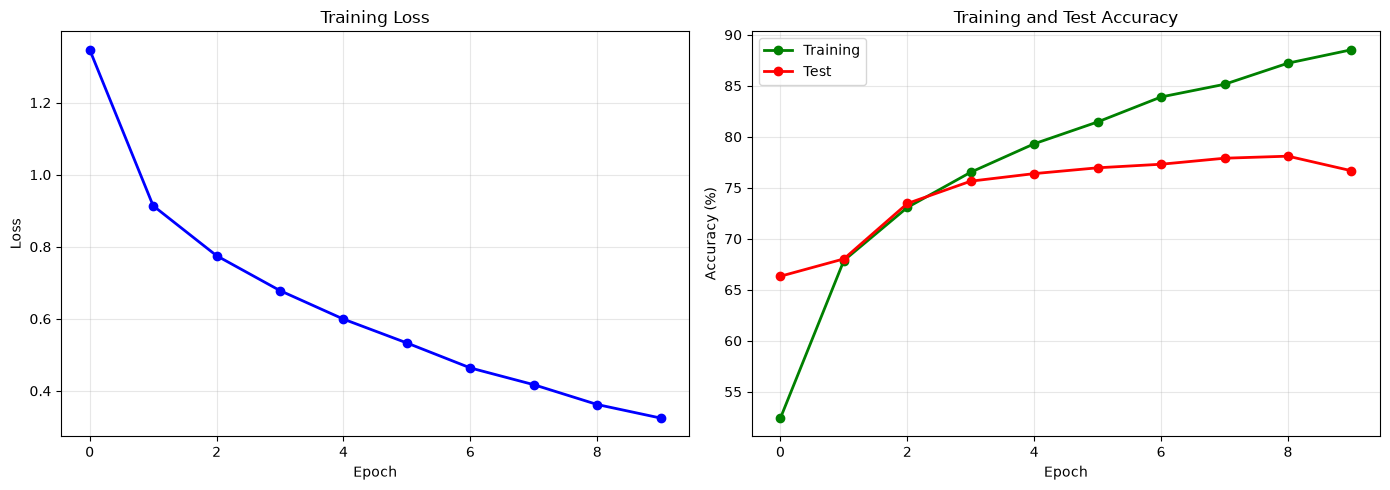


Final Training Accuracy: 88.53%
Final Test Accuracy: 76.67%
Overfitting Gap: 11.86%


In [13]:
print("\n" + "="*60)
print("ANALYZING TRAINING PROGRESS")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, 'bo-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(train_accuracies, 'go-', linewidth=2, label='Training')
ax2.plot(test_accuracies, 'ro-', linewidth=2, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Overfitting Gap: {train_accuracies[-1] - test_accuracies[-1]:.2f}%")



MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

       plane     0.8431    0.7200    0.7767      1000
         car     0.8678    0.8600    0.8639      1000
        bird     0.7381    0.6510    0.6918      1000
         cat     0.6179    0.6000    0.6088      1000
        deer     0.7792    0.7340    0.7559      1000
         dog     0.6739    0.6860    0.6799      1000
        frog     0.7057    0.9090    0.7946      1000
       horse     0.9275    0.7040    0.8005      1000
        ship     0.8141    0.9020    0.8558      1000
       truck     0.7591    0.9010    0.8240      1000

    accuracy                         0.7667     10000
   macro avg     0.7726    0.7667    0.7652     10000
weighted avg     0.7726    0.7667    0.7652     10000



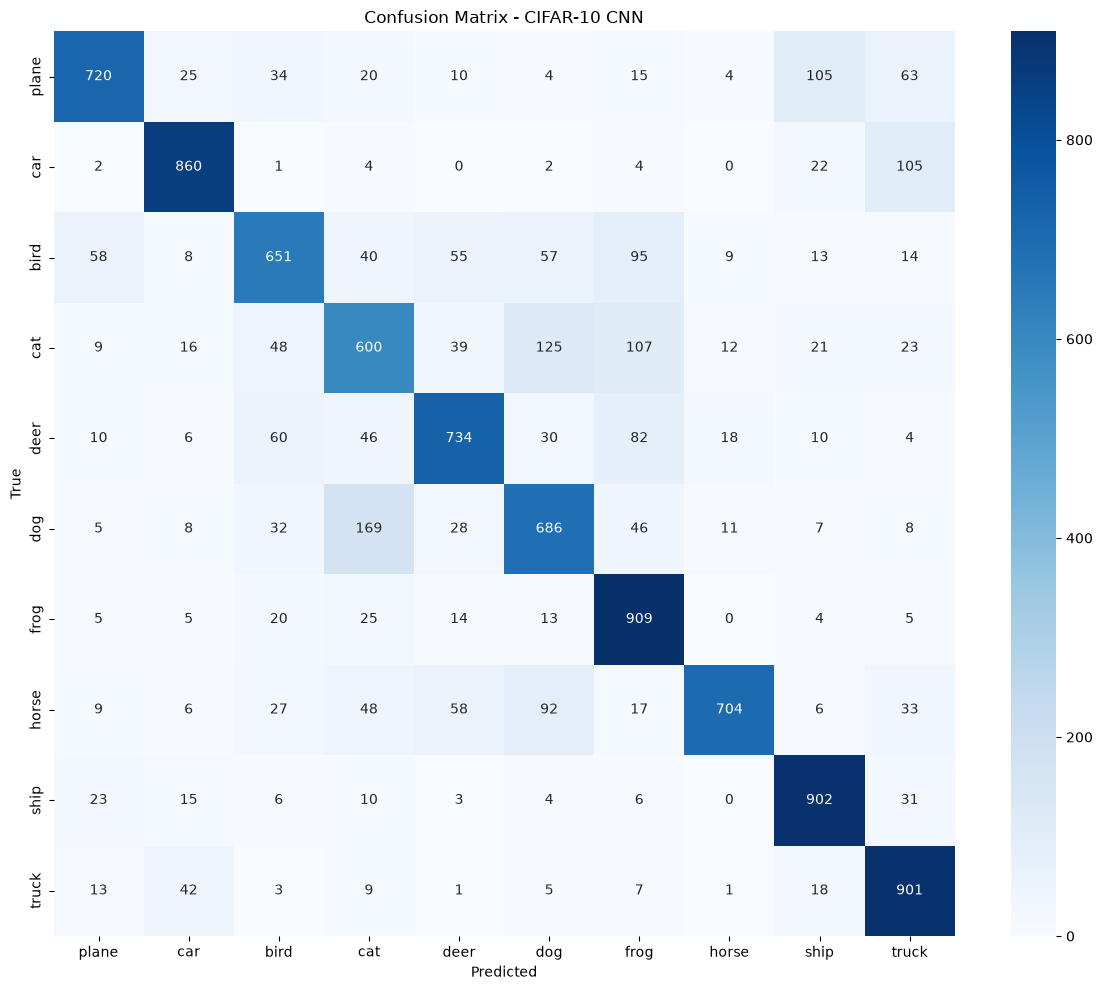

In [14]:
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Get all predictions
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CIFAR-10 CNN')
plt.tight_layout()
plt.show()


VISUALIZING CNN FILTERS


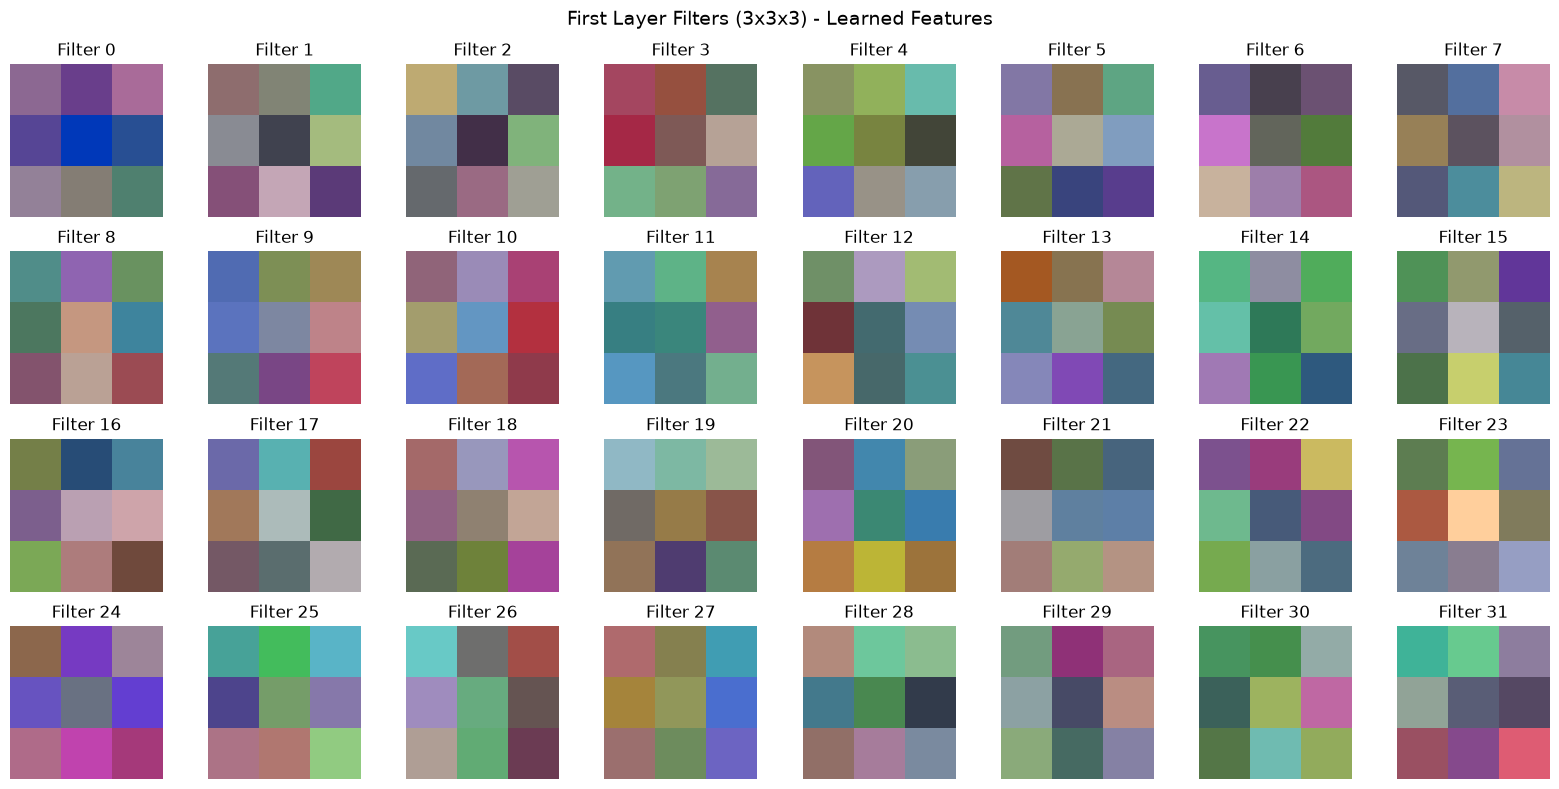


WHAT THE FILTERS LEARNED:

• Some filters detect edges (horizontal, vertical)
• Some filters detect colors
• Some filters detect textures
• These are the basic building blocks of image recognition!

In deeper layers, filters detect more complex patterns:
  Layer 1: Edges, colors
  Layer 2: Shapes, textures
  Layer 3: Object parts (eyes, wheels, etc.)
  Layer 4: Full objects (cats, cars, etc.)



In [15]:
print("\n" + "="*60)
print("VISUALIZING CNN FILTERS")
print("="*60)

# Get first layer filters
filters = model.conv1.weight.detach().numpy()

# Normalize filters for visualization
filters = (filters - filters.min()) / (filters.max() - filters.min())

# Plot filters
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.ravel()

for i in range(32):
    # Get filter (3, 3, 3) and convert to displayable format
    filter_img = filters[i].transpose(1, 2, 0)
    axes[i].imshow(filter_img)
    axes[i].axis('off')
    axes[i].set_title(f'Filter {i}')

plt.suptitle('First Layer Filters (3x3x3) - Learned Features', fontsize=14)
plt.tight_layout()
plt.show()

print("""
WHAT THE FILTERS LEARNED:

• Some filters detect edges (horizontal, vertical)
• Some filters detect colors
• Some filters detect textures
• These are the basic building blocks of image recognition!

In deeper layers, filters detect more complex patterns:
  Layer 1: Edges, colors
  Layer 2: Shapes, textures
  Layer 3: Object parts (eyes, wheels, etc.)
  Layer 4: Full objects (cats, cars, etc.)
""")



PART 9: VISUALIZING PREDICTIONS


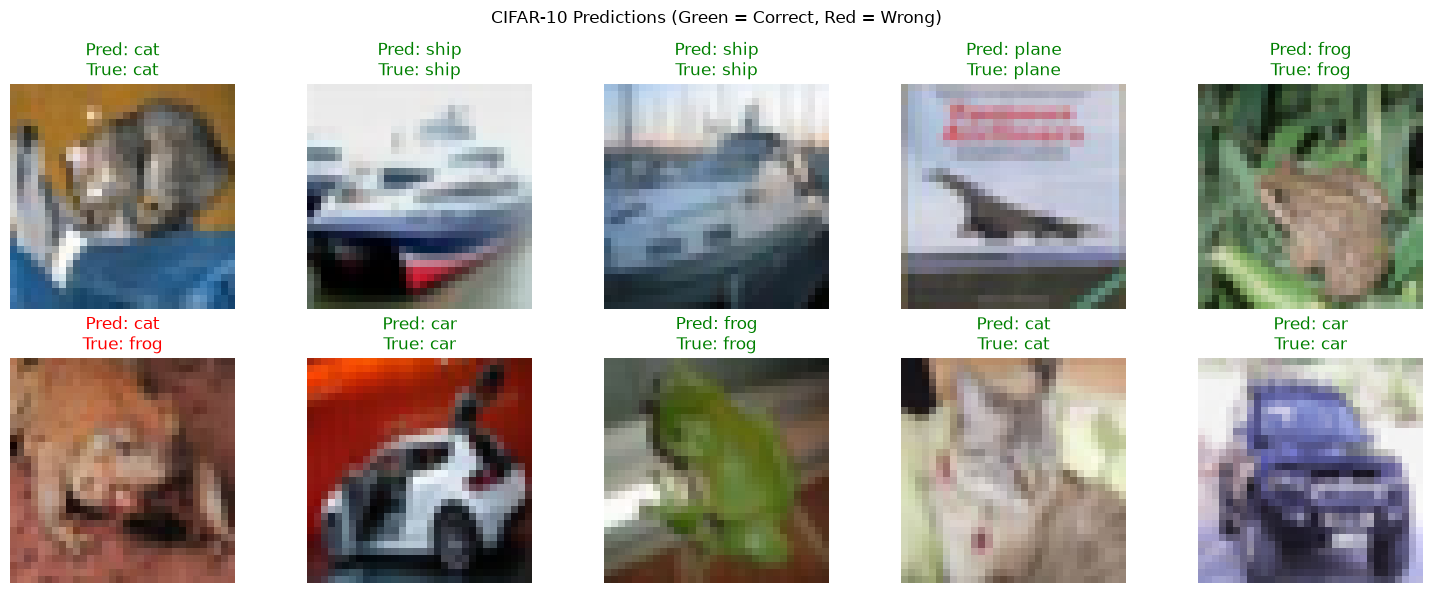


Sample 0: True = cat
Confidence scores:
  plane   :   0.0% 
  car     :   0.5% 
  bird    :   0.0% 
  cat     :  90.2% █████████████████████████████████████████████
  deer    :   0.0% 
  dog     :   6.4% ███
  frog    :   0.2% 
  horse   :   0.0% 
  ship    :   2.6% █
  truck   :   0.1% 


In [16]:
print("\n" + "="*60)
print("PART 9: VISUALIZING PREDICTIONS")
print("="*60)

# Get some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    probabilities = torch.softmax(outputs, dim=1)

# Show images with predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    img = images[i] / 2 + 0.5
    img = img.permute(1, 2, 0)
    axes[i].imshow(img)
    pred = predicted[i].item()
    true = labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'Pred: {classes[pred]}\nTrue: {classes[true]}', color=color)
    axes[i].axis('off')

plt.suptitle('CIFAR-10 Predictions (Green = Correct, Red = Wrong)')
plt.tight_layout()
plt.show()

# Show confidence scores for one sample
sample_idx = 0
probs = probabilities[sample_idx].numpy()

print(f"\nSample {sample_idx}: True = {classes[labels[sample_idx].item()]}")
print("Confidence scores:")
for i, prob in enumerate(probs):
    bar = '█' * int(prob * 50)
    print(f"  {classes[i]:8s}: {prob*100:5.1f}% {bar}")

### Key CNN Concepts

#### 1. Convolution
- Filters slide across image
- Detect local patterns
- Share weights (fewer parameters!)

#### 2. Pooling
- MaxPool2d reduces spatial dimensions
- Keeps important features
- Reduces computation

#### 3. Architecture
- Conv → BatchNorm → ReLU → MaxPool (repeat)
- Flatten → Dense → Dropout → Output

#### 4. Why CNNs Work
- Translation invariance (cat is cat anywhere)
- Fewer parameters than dense networks
- Hierarchical feature learning

#### 5. Performance
| Model | Accuracy on CIFAR-10 |
|---|---|
| Simple CNN | ~70–75% |
| Deeper CNNs | ~90–95% |
| State-of-the-art | ~99% |


## Comparison with Dense Network

- **Dense:** `784 → 128 → 10` (MNIST)
- **CNN:** `3x32x32 → conv layers → 10` (CIFAR-10)
- CNN handles spatial structure much better!